# Day 2 - Understanding and visualising Cell Painting data

Data Science for Life Scientists

Today we will inspect a processed Cell Painting dataset and connect it to one ToxCast cytotoxicity endpoint. The goal is to understand what each table contains, why the tables need to be merged, and whether morphology patterns line up with a selected biological label.

We will use:

- Cell Painting Level 6 consensus profiles: one row per compound and many image-derived feature columns.
- Compound metadata: the bridge between compound names and `OASIS_ID` identifiers.
- ToxCast cytotoxicity labels: binary active/inactive annotations for assay groups such as `tissue__liver`.


## 1. Setup


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Some scientific Python packages still expect these old NumPy aliases.
for alias, value in {"float": float, "int": int, "bool": bool, "str": str}.items():
    if alias not in np.__dict__:
        setattr(np, alias, value)

import umap

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("../../inputs")
RANDOM_STATE = 42


/Users/ollitrault/Documents/projects/2026_DataScienceForLifeScientists_Training/cp-training/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load the tables

Before plotting, check what the dataset actually contains. This helps separate metadata columns, feature columns, and biological label columns.


In [5]:
df_cell_painting = pd.read_parquet(DATA_DIR / "level6_axiom_selected_features.parquet")
df_compounds_infos = pd.read_csv(DATA_DIR / "v5_oasis_03Sept2024_simple.csv")
df_toxcast_cytotox = pd.read_parquet(DATA_DIR / "toxcast_cytotox_binary.parquet")

raw_feature_cols = [col for col in df_cell_painting.columns if col.startswith("Feature_")]
raw_metadata_cols = [col for col in df_cell_painting.columns if col.startswith("Metadata_")]
toxcast_assay_cols = [col for col in df_toxcast_cytotox.columns if col != "OASIS_ID"]

table_summary = pd.DataFrame(
    [
        {
            "table": "Cell Painting Level 6 profiles",
            "rows": df_cell_painting.shape[0],
            "columns": df_cell_painting.shape[1],
            "key column": "Metadata_compound",
        },
        {
            "table": "Compound metadata",
            "rows": df_compounds_infos.shape[0],
            "columns": df_compounds_infos.shape[1],
            "key column": "PREFERRED_NAME / OASIS_ID",
        },
        {
            "table": "ToxCast cytotoxicity labels",
            "rows": df_toxcast_cytotox.shape[0],
            "columns": df_toxcast_cytotox.shape[1],
            "key column": "OASIS_ID",
        },
    ]
)

print(f"Cell Painting metadata columns: {len(raw_metadata_cols):,}")
print(f"Cell Painting feature columns: {len(raw_feature_cols):,}")
print(f"ToxCast cytotoxicity endpoints: {len(toxcast_assay_cols):,}")
display(table_summary)


Cell Painting metadata columns: 5
Cell Painting feature columns: 4,434
ToxCast cytotoxicity endpoints: 38


,table,rows,columns,key column
0,Cell Painting Level 6 profiles,1086,4439,Metadata_compound
1,Compound metadata,1494,20,PREFERRED_NAME / OASIS_ID
2,ToxCast cytotoxicity labels,963,39,OASIS_ID


In [6]:
# Preview the Cell Painting table. Each feature is a quantitative summary of cell morphology.
df_cell_painting.head()

,Metadata_compound,Feature_DNA_1,Feature_DNA_2,Feature_DNA_3,Feature_DNA_4,Feature_DNA_6,Feature_DNA_8,Feature_DNA_9,Feature_DNA_11,Feature_DNA_12,...,Feature_Brightfield_763,Feature_Brightfield_764,Feature_Brightfield_765,Feature_Brightfield_766,Feature_Brightfield_767,Feature_Brightfield_768,Metadata_compound_target,Metadata_compound_pathway,Metadata_compound_research_area,Metadata_compound_clinical_information
0,(2r)-2-(4-Chloro-2-methylphenoxy)propanoic acid,0.293698,-0.174230,0.189297,-0.024075,-0.191541,0.199596,-0.174870,-0.321783,-0.354293,...,0.589849,-0.744322,0.157313,0.056248,-0.031834,0.001477,None,None,None,None
1,(E/Z)-Belinostat,-0.211621,-0.069363,-0.280629,-0.545720,1.852452,0.101376,0.710016,1.330465,1.124382,...,-0.143356,0.279176,0.164607,-0.619689,0.523417,-0.758453,Apoptosis; HDAC,Apoptosis; Cell Cycle/DNA Damage; Epigenetics,Cancer,No Development Reported
2,"1,1-Dioxothiolan",0.062582,-0.153051,0.008234,-0.623874,0.098987,0.006973,-0.255372,-0.036348,-0.171204,...,0.449012,-0.153327,-0.229005,-0.124882,0.059801,0.069813,None,None,None,No Development Reported
3,"1,3,5-Triallyl-1,3,5-triazinane-2,4,6-trione",0.022345,-0.455648,0.265137,-0.592919,-0.136539,-0.061573,-0.676081,-0.511206,-0.294391,...,-0.284356,-0.203208,0.148358,0.293030,0.441266,0.580031,None,None,None,No Development Reported
4,"1,4-Benzodinitrile",0.258364,-0.654667,0.763847,-0.105961,-0.133511,-0.606303,0.003507,0.310333,-0.009760,...,0.344701,-0.281939,-0.322446,-0.132672,-0.140758,-0.116839,None,None,None,No Development Reported


In [7]:
feature_channels = (
    pd.Series(raw_feature_cols, name="feature")
    .str.extract(r"^Feature_([^_]+)_", expand=False)
    .fillna("unknown")
)

channel_summary = (
    feature_channels.value_counts()
    .rename_axis("channel")
    .reset_index(name="n_features")
)

metadata_preview = pd.DataFrame(
    {
        "Cell Painting metadata columns": raw_metadata_cols,
    }
)

display(channel_summary)
display(metadata_preview)


,channel,n_features
0,AGP,767
1,Brightfield,766
2,Mito,759
3,RNA,754
4,ER,746
5,DNA,642


,Cell Painting metadata columns
0,Metadata_compound
1,Metadata_compound_target
2,Metadata_compound_pathway
3,Metadata_compound_research_area
4,Metadata_compound_clinical_information


### Quick question

- Which columns describe the compound rather than the cell phenotype?
- What does one row of the Level 6 Cell Painting table represent?

## 3. Merge Cell Painting profiles with cytotoxicity labels

The tables cannot be joined directly because they use different compound identifiers. The merge path is:

`Metadata_compound` -> `PREFERRED_NAME` -> `OASIS_ID` -> ToxCast cytotoxicity labels

The metadata table acts as a lookup table. It translates the compound name used in the Cell Painting profiles into the `OASIS_ID` used by ToxCast.


In [8]:
# A few names are repeated in the metadata table. Dropping duplicates prevents one
# Cell Painting row from expanding into multiple rows during the lookup merge.
df_compounds_infos_unique = df_compounds_infos.drop_duplicates(subset="PREFERRED_NAME").copy()

# First merge: attach OASIS_ID values to Cell Painting rows by matching compound names.
df_cell_painting_compounds_infos = df_cell_painting.merge(
    df_compounds_infos_unique,
    how="left",
    left_on="Metadata_compound",
    right_on="PREFERRED_NAME",
    validate="many_to_one",
)

# Second merge: keep compounds that also have cytotoxicity labels.
df_viz = df_cell_painting_compounds_infos.merge(
    df_toxcast_cytotox,
    how="inner",
    on="OASIS_ID",
    validate="many_to_one",
)

merge_summary = pd.DataFrame(
    [
        {"step": "Cell Painting compounds", "n_compounds": len(df_cell_painting)},
        {
            "step": "With OASIS_ID after metadata lookup",
            "n_compounds": df_cell_painting_compounds_infos["OASIS_ID"].notna().sum(),
        },
        {"step": "With cytotoxicity labels after inner merge", "n_compounds": len(df_viz)},
    ]
)

display(merge_summary)
df_viz[["Metadata_compound", "PREFERRED_NAME", "OASIS_ID"]].head()


,step,n_compounds
0,Cell Painting compounds,1086
1,With OASIS_ID after metadata lookup,791
2,With cytotoxicity labels after inner merge,551


,Metadata_compound,PREFERRED_NAME,OASIS_ID
0,"1,4-Dibromobenzene","1,4-Dibromobenzene",OASIS548
1,"1,4-Dichlorobenzene","1,4-Dichlorobenzene",OASIS292
2,"1,6-Dichlorohexane","1,6-Dichlorohexane",OASIS287
3,1-Naphthaleneacetic acid,1-Naphthaleneacetic acid,OASIS370
4,"2,6-Diaminopyridine","2,6-Diaminopyridine",OASIS381


### Your turn

- How many Cell Painting compounds were lost when we required a cytotoxicity label?
- Why is `how="left"` useful for the metadata lookup, but `how="inner"` useful for the final labelled dataset?
- What could cause a compound name to fail to map to an `OASIS_ID`?


## 4. Choose one cytotoxicity endpoint

Each ToxCast cytotoxicity column is binary: `1` means active and `0` means inactive. We will use one selected endpoint for the rest of the notebook.


In [9]:
feature_cols = [col for col in df_viz.columns if col.startswith("Feature_")]
toxcast_assay_cols = [col for col in df_toxcast_cytotox.columns if col != "OASIS_ID"]

target_summary = df_viz[toxcast_assay_cols].agg(["sum", "count"]).T
target_summary = target_summary.rename(columns={"sum": "n_active", "count": "n_tested"})
target_summary["n_inactive"] = target_summary["n_tested"] - target_summary["n_active"]
target_summary["active_fraction"] = target_summary["n_active"] / target_summary["n_tested"]

display(target_summary.sort_values("active_fraction", ascending=False).head(10))


,n_active,n_tested,n_inactive,active_fraction
tissue__pluripotent_cell_line,15.0,26.0,11.0,0.576923
cell_type__RUES2-GLR,15.0,26.0,11.0,0.576923
cell_type__VM7Luc4E2,4.0,7.0,3.0,0.571429
tissue__mammary_gland/breast,4.0,7.0,3.0,0.571429
tissue__prostate,74.0,150.0,76.0,0.493333
cell_type__22Rv1,74.0,150.0,76.0,0.493333
tissue__H9-derived_neuroprogenitor_stem_cells,6.0,13.0,7.0,0.461538
cell_type__hNP1,6.0,13.0,7.0,0.461538
cell_type__HEK293,158.0,485.0,327.0,0.325773
cell_type__T47D,55.0,186.0,131.0,0.295699


In [10]:
# Change this value to explore a different cytotoxicity endpoint.
SELECTED_CYTOTOXICITY = "tissue__liver"

if SELECTED_CYTOTOXICITY not in toxcast_assay_cols:
    raise ValueError(f"{SELECTED_CYTOTOXICITY} is not a valid cytotoxicity endpoint.")

df_plot = df_viz.dropna(subset=[SELECTED_CYTOTOXICITY]).reset_index(drop=True).copy()
df_plot["cytotoxicity_label"] = (
    df_plot[SELECTED_CYTOTOXICITY]
    .astype(int)
    .map({0: "inactive", 1: "active"})
)

class_balance = (
    df_plot["cytotoxicity_label"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="n_compounds")
)
class_balance["fraction"] = class_balance["n_compounds"] / class_balance["n_compounds"].sum()

print(f"Selected endpoint: {SELECTED_CYTOTOXICITY}")
display(target_summary.loc[[SELECTED_CYTOTOXICITY]])
display(class_balance)


Selected endpoint: tissue__liver


,n_active,n_tested,n_inactive,active_fraction
tissue__liver,130.0,548.0,418.0,0.237226


,class,n_compounds,fraction
0,inactive,418,0.762774
1,active,130,0.237226


### Quick question

- Is `tissue__liver` balanced or imbalanced in this dataset?
- If active compounds form a visible group in a morphology plot, what might that suggest?
- If active compounds are spread across the plot, what are two possible explanations?


## 5. Prepare features for visualisation

Cell Painting profiles contain thousands of features. For a readable clustermap and a fast UMAP, we will impute missing values, scale features, and keep the most variable features.


In [11]:
N_FEATURES_FOR_PLOTS = 300

X = df_plot[feature_cols].copy()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(imputer.fit_transform(X)),
    columns=feature_cols,
    index=df_plot.index,
)

top_variable_features = (
    X_scaled.var()
    .sort_values(ascending=False)
    .head(N_FEATURES_FOR_PLOTS)
    .index
    .to_list()
)

X_plot = X_scaled[top_variable_features]

print(f"Compounds with {SELECTED_CYTOTOXICITY} labels: {len(df_plot):,}")
print(f"Features used for plots: {len(top_variable_features):,}")


Compounds with tissue__liver labels: 548
Features used for plots: 300


## 6. Clustermap

The clustermap groups compounds with similar Cell Painting profiles. Rows are coloured by the selected cytotoxicity label, so we can ask whether active compounds tend to cluster together.


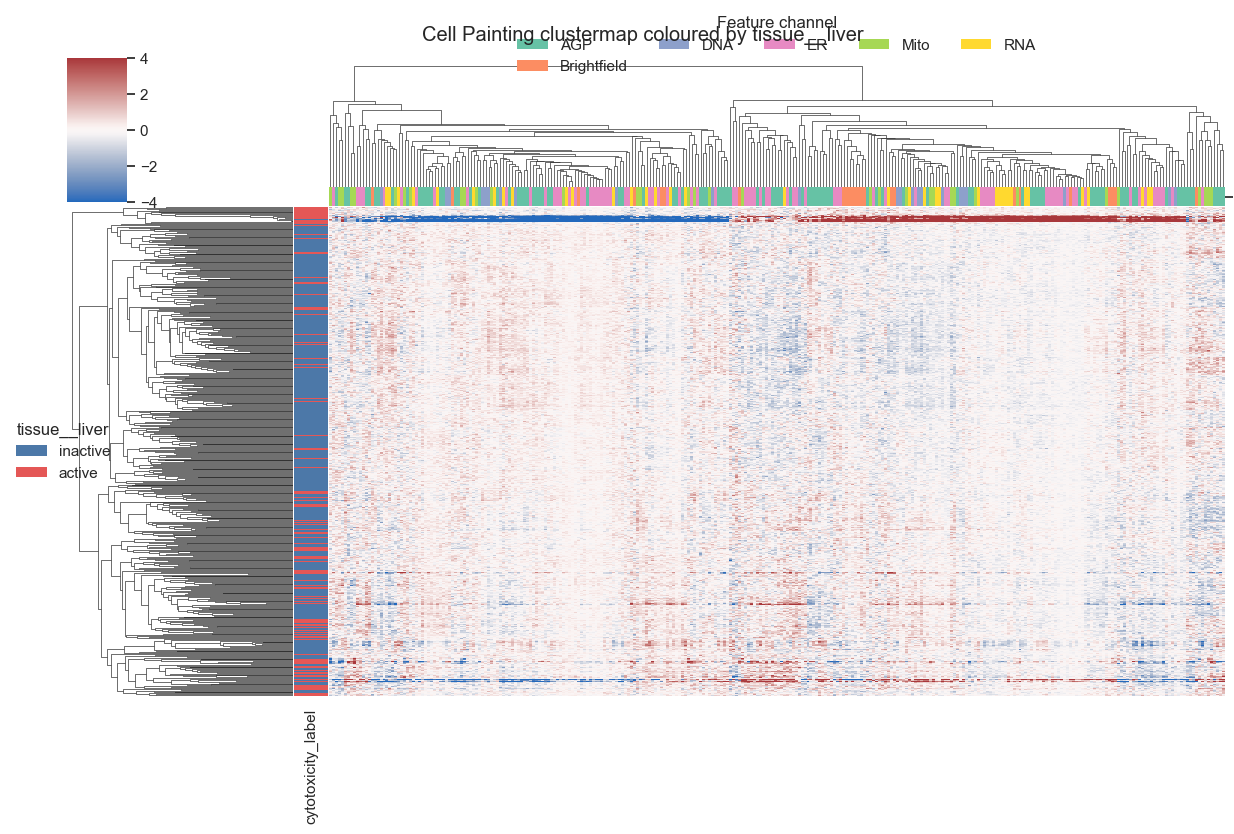

In [12]:
label_palette = {"inactive": "#4C78A8", "active": "#E45756"}
row_colors = df_plot["cytotoxicity_label"].map(label_palette)

plot_feature_channels = (
    pd.Series(top_variable_features, index=top_variable_features)
    .str.extract(r"^Feature_([^_]+)_", expand=False)
    .fillna("unknown")
)
channel_names = sorted(plot_feature_channels.unique())
channel_palette = dict(zip(channel_names, sns.color_palette("Set2", len(channel_names))))
col_colors = plot_feature_channels.map(channel_palette)

cluster_data = X_plot.clip(lower=-4, upper=4)

g = sns.clustermap(
    cluster_data,
    cmap="vlag",
    center=0,
    vmin=-4,
    vmax=4,
    row_colors=row_colors,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=False,
    figsize=(12, 8),
    method="average",
    metric="correlation",
)

g.fig.suptitle(
    f"Cell Painting clustermap coloured by {SELECTED_CYTOTOXICITY}",
    y=1.02,
)

for label, color in label_palette.items():
    g.ax_row_dendrogram.bar(0, 0, color=color, label=label, linewidth=0)
g.ax_row_dendrogram.legend(
    title=SELECTED_CYTOTOXICITY,
    loc="center left",
    bbox_to_anchor=(-0.25, 0.5),
    frameon=False,
)

for label, color in channel_palette.items():
    g.ax_col_dendrogram.bar(0, 0, color=color, label=label, linewidth=0)
g.ax_col_dendrogram.legend(
    title="Feature channel",
    loc="center",
    ncol=min(5, len(channel_names)),
    bbox_to_anchor=(0.5, 1.12),
    frameon=False,
)

plt.show()


### Your turn

- Do active `tissue__liver` compounds cluster together, or are they distributed across many clusters?

## 7. UMAP

UMAP places compounds with similar high-dimensional profiles near each other in two dimensions. We colour points by the same selected cytotoxicity label used in the clustermap.


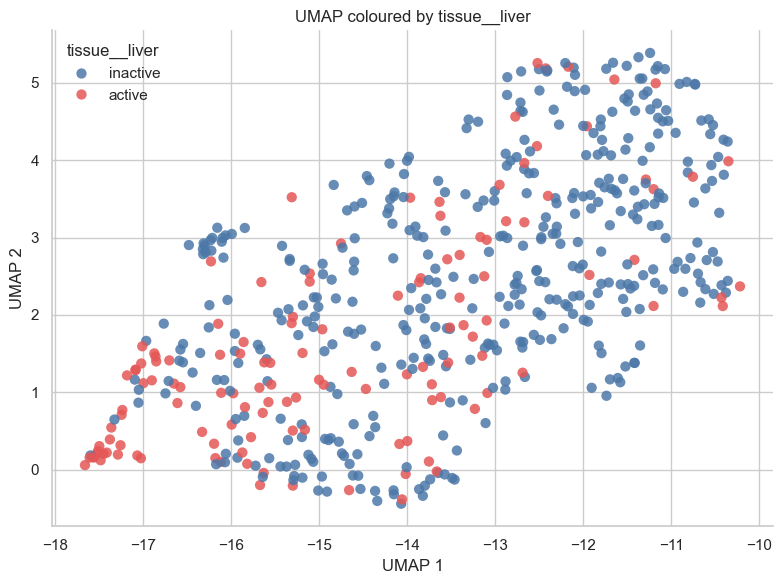

In [13]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=RANDOM_STATE,
)
embedding = reducer.fit_transform(X_plot)

df_umap = df_plot[
    ["Metadata_compound", "PREFERRED_NAME", "OASIS_ID", SELECTED_CYTOTOXICITY, "cytotoxicity_label"]
].copy()
df_umap["UMAP1"] = embedding[:, 0]
df_umap["UMAP2"] = embedding[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df_umap,
    x="UMAP1",
    y="UMAP2",
    hue="cytotoxicity_label",
    hue_order=["inactive", "active"],
    palette=label_palette,
    s=55,
    alpha=0.85,
    linewidth=0,
    ax=ax,
)

ax.set_title(f"UMAP coloured by {SELECTED_CYTOTOXICITY}")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend(title=SELECTED_CYTOTOXICITY, frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


### Your turn

- Do active compounds occupy one region of the UMAP or several regions?
- How might this exploratory plot inform the supervised ML and deep-learning notebooks later in the course?
